# Air Quality Data Cleaning Using R
Submission-ready notebook

In [1]:
# Install packages if needed
# install.packages(c("ggplot2"))
library(ggplot2)

file_name <- "/content/drive/MyDrive/R programming/PRSA_Data_Aotizhongxin_20130301-20170228.csv"
air_data <- tryCatch({
  read.csv(file_name)
}, error=function(e){stop("File error: ",e$message)})

head(air_data)
str(air_data)
dim(air_data)
sum(is.na(air_data))


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,1,2013,3,1,0,4,4,4,7,300,77,-0.7,1023.0,-18.8,0,NNW,4.4,Aotizhongxin
2,2,2013,3,1,1,8,8,4,7,300,77,-1.1,1023.2,-18.2,0,N,4.7,Aotizhongxin
3,3,2013,3,1,2,7,7,5,10,300,73,-1.1,1023.5,-18.2,0,NNW,5.6,Aotizhongxin
4,4,2013,3,1,3,6,6,11,11,300,72,-1.4,1024.5,-19.4,0,NW,3.1,Aotizhongxin
5,5,2013,3,1,4,3,3,12,12,300,72,-2.0,1025.2,-19.5,0,N,2.0,Aotizhongxin
6,6,2013,3,1,5,5,5,18,18,400,66,-2.2,1025.6,-19.6,0,N,3.7,Aotizhongxin


'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hour   : int  0 1 2 3 4 5 6 7 8 9 ...
 $ PM2.5  : num  4 8 7 6 3 5 3 3 3 3 ...
 $ PM10   : num  4 8 7 6 3 5 3 6 6 8 ...
 $ SO2    : num  4 4 5 11 12 18 18 19 16 12 ...
 $ NO2    : num  7 7 10 11 12 18 32 41 43 28 ...
 $ CO     : int  300 300 300 300 300 400 500 500 500 400 ...
 $ O3     : num  77 77 73 72 72 66 50 43 45 59 ...
 $ TEMP   : num  -0.7 -1.1 -1.1 -1.4 -2 -2.2 -2.6 -1.6 0.1 1.2 ...
 $ PRES   : num  1023 1023 1024 1024 1025 ...
 $ DEWP   : num  -18.8 -18.2 -18.2 -19.4 -19.5 -19.6 -19.1 -19.1 -19.2 -19.3 ...
 $ RAIN   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ wd     : chr  "NNW" "N" "NNW" "NW" ...
 $ WSPM   : num  4.4 4.7 5.6 3.1 2 3.7 2.5 3.8 4.1 2.6 ...
 $ station: chr  "Aotizhongxin" "Aotizhongxin" "Aotizhongxin" "Aotizhongxin" ...


[1] 35064    18

[1] 7271

## Task 2: NA, NULL, NaN

In [2]:
temperature<-c(28,30,NA,32)
missing_object<-NULL
undefined_value<-0/0
is.na(temperature)
is.null(missing_object)
is.nan(undefined_value)


[1] FALSE FALSE  TRUE FALSE

[1] TRUE

[1] TRUE

## Tasks 3-10

  Variable Total Missing Percent
1    PM2.5 35064       0       0
2     PM10 35064       0       0
3      SO2 35064       0       0
4      NO2 35064       0       0
5     TEMP 35064       0       0
6     WSPM 35064       0       0
7       wd 35064       0       0
      Variable Missing_Before Missing_After Values_Replaced
PM2.5    PM2.5              0             0               0
PM10      PM10              0             0               0
SO2        SO2              0             0               0
NO2        NO2              0             0               0
TEMP      TEMP              0             0               0
WSPM      WSPM              0             0               0
wd          wd              0             0               0


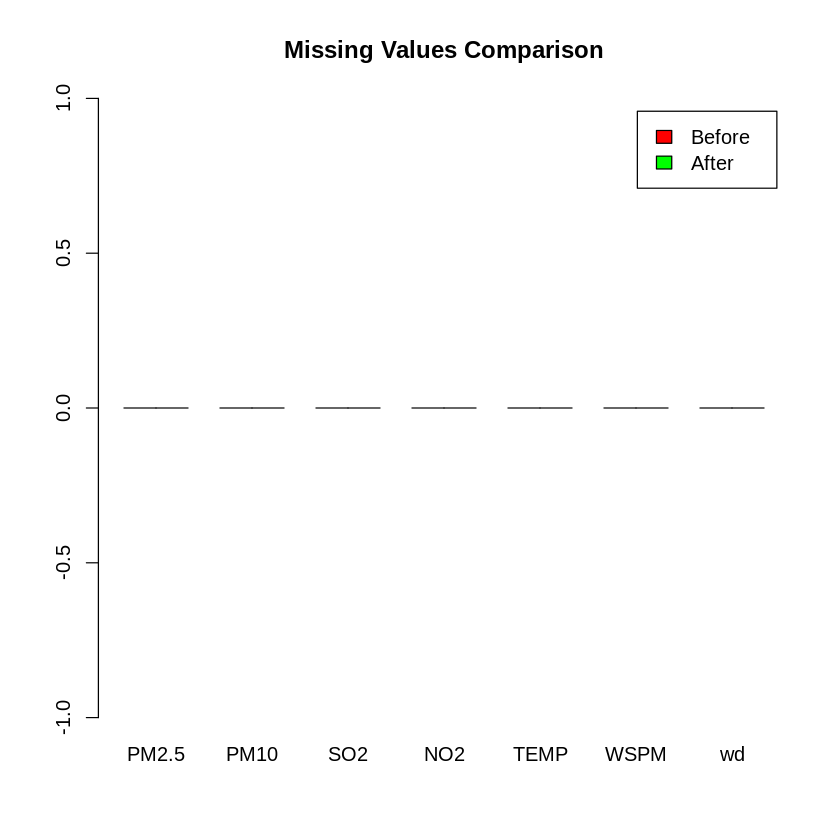

In [4]:
missing_summary<-function(df){
vars<-c("PM2.5","PM10","SO2","NO2","TEMP","WSPM","wd")
res<-data.frame()
for(v in vars){
 if(v%in%names(df)){
  m<-sum(is.na(df[[v]])); t<-nrow(df); p<-100*m/t
  if(p>20) warning(paste(v,"has >20% missing"))
  res<-rbind(res,data.frame(Variable=v,Total=t,Missing=m,Percent=round(p,2)))
 }
}
print(res);res}
summary_before<-missing_summary(air_data)

air_data$pollution_ratio<-air_data$PM2.5/air_data$PM10
air_data$pollution_ratio[is.nan(air_data$pollution_ratio)|is.infinite(air_data$pollution_ratio)]<-NA

numeric_variables<-c("PM2.5","PM10","SO2","NO2","TEMP","WSPM")
before<-sapply(c(numeric_variables,"wd"),function(x)sum(is.na(air_data[[x]])))
for(v in numeric_variables){
 if(v%in%names(air_data)){
  med<-median(air_data[[v]],na.rm=TRUE)
  air_data[[v]][is.na(air_data[[v]])]<-med
 }
}
calculate_mode<-function(x){
 ux<-na.omit(unique(x))
 ux[which.max(tabulate(match(x,ux)))]
}
mode_wd<-calculate_mode(air_data$wd)
air_data$wd[is.na(air_data$wd)]<-mode_wd

clean_variable<-function(df,var){
tryCatch({
 if(!(var%in%names(df))) stop("Variable not found")
 if(!is.numeric(df[[var]])) stop("Not numeric")
 if(all(is.na(df[[var]]))) stop("All values missing")
 med<-median(df[[var]],na.rm=TRUE)
 df[[var]][is.na(df[[var]])]<-med
 df[[var]]
},error=function(e){message(e$message);NULL})
}
after<-sapply(c(numeric_variables,"wd"),function(x)sum(is.na(air_data[[x]])))
comparison<-data.frame(Variable=c(numeric_variables,"wd"),Missing_Before=before,Missing_After=after,Values_Replaced=before-after)
print(comparison)

barplot(rbind(before,after),beside=TRUE,col=c("red","green"),
legend.text=c("Before","After"),main="Missing Values Comparison")

write.csv(air_data,"cleaned_air_quality_data.csv",row.names=FALSE)
